Papers:
* https://www.ceeol.com/search/article-detail?id=746689 - Kayleb

* https://www.researchgate.net/profile/A-Chandak/publication/335799148_Car_Price_Prediction_Using_Machine_Learning/links/61c46128c48a3d26b74b3c6e/Car-Price-Prediction-Using-Machine-Learning.pdf -Ethan

* https://ieeexplore.ieee.org/abstract/document/10544124 -Kayleb

* https://ieeexplore.ieee.org/abstract/document/9800719

* https://www.mdpi.com/2071-1050/14/24/17034 -Theo

* https://www.researchgate.net/profile/Yavuz-Balcioglu/publication/379443793_CAR_PRICE_PREDICTION_USING_MACHINE_LEARNING_TECHNIQUES/links/66098eddf5a5de0a9ff0ca87/CAR-PRICE-PREDICTION-USING-MACHINE-LEARNING-TECHNIQUES.pdf -Theo

* https://www.researchgate.net/profile/Aravind-Sasidharan-Pillai/publication/379035407_A_Deep_Learning_Approach_for_Used_Car_Price_Prediction/links/65f74e62c05fd268801f2715/A-Deep-Learning-Approach-for-Used-Car-Price-Prediction.pdf -Ethan

Dataset
https://www.kaggle.com/datasets/tunguz/used-car-auction-prices

Also Dataset?
https://console.cloud.google.com/bigquery?ws=!1m5!1m4!4m3!1scst324-473918!2scarIdentification!3scarTable

Paper

https://oregontech-my.sharepoint.com/:w:/g/personal/ethan_chinander_oit_edu/IQCROls0oaT_R4Sn3sy3Zir0AWzLZG3dm9uX8E_TZA1dYn0?e=6k8cVi&CID=d4cf1f64-7576-afc1-0731-38b790bf71c2

Presentation

https://oregontech-my.sharepoint.com/:p:/g/personal/ethan_chinander_oit_edu/IQDarHfXRsfLRrv47YKXp_hlARjgdO6shX43Lf5hKe99EzA?e=qzhAVf&CID=062163a7-a398-7168-83cd-f6761f040d7a



In [2]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery
from google.colab import data_table
import bigframes.pandas as bpd
import sklearn as sk
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

project_id = 'cst324-473918'
location = 'US' # Location inserted based on the query results selected to explore
client = bigquery.Client(project=project_id, location=location)
data_table.enable_dataframe_formatter()

sql_query = ('''SELECT * FROM `cst324-473918.carIdentification.carTable`''')

df = client.query(sql_query).to_dataframe()

sql_query2 = ''' SELECT make,AVG(sellingprice) as avgprice FROM cst324-473918.carIdentification.carTable
GROUP BY make
ORDER BY avgprice desc'''

df2 = client.query(sql_query2).to_dataframe()

sql_query3 = '''
SELECT sellingprice
FROM `cst324-473918.carIdentification.carTable`
WHERE sellingprice IS NOT NULL
AND sellingprice > 0
AND sellingprice < 100000
'''

df3 = client.query(sql_query3).to_dataframe()


,year,make,model,body,transmission,state,condition,odometer,sellingprice
0,1984,Chevrolet,Corvette,Coupe,automatic,md,2.0,46891,3100
1,1986,Chevrolet,Corvette,Coupe,manual,nj,4.0,12466,8600
2,1990,Mercedes-Benz,300-Class,Sedan,automatic,nv,2.0,141799,300
3,1990,Nissan,300ZX,Hatchback,None,nv,2.0,152736,1500
4,1990,Toyota,4Runner,SUV,None,va,1.0,164016,500
...,...,...,...,...,...,...,...,...,...
535262,2015,BMW,Z4,Convertible,automatic,oh,4.9,5397,40500
535263,2015,BMW,Z4,Convertible,automatic,oh,4.6,12189,42250
535264,2015,BMW,Z4,Convertible,automatic,oh,4.5,3698,51500
535265,2015,smart,fortwo,Hatchback,automatic,ca,5.0,338,9000


Text(0.5, 1.0, 'Selling Price by other factors')

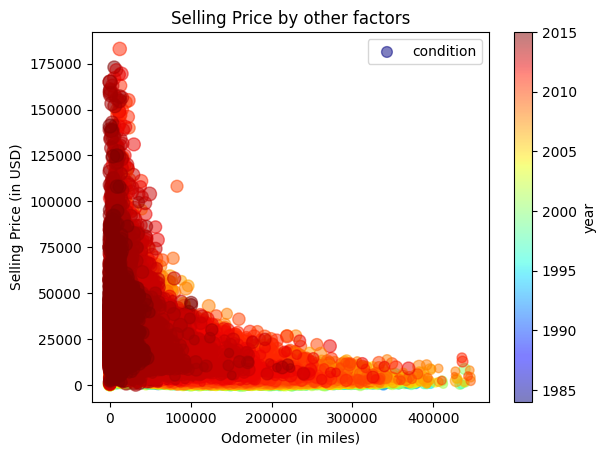

In [ ]:
#lab3 was IRIS lab
#Implement machine learning model
#https://scikit-learn.org/stable/supervised_learning.html

display(df) #For Testing, display dataframe output


#Visualization 1: Scatterplot of Odometer compared with Car Sales Price
vis1 = df.copy()
vis1 = vis1[vis1["odometer"].between(0, 450000, inclusive="right")]
vis1 = vis1[vis1["sellingprice"].between(0, 200000, inclusive="right")]
vis1["condition_scaled"] = vis1["condition"] * 20
vis1.plot.scatter(x="odometer", xlabel="Odometer (in miles)", y="sellingprice", ylabel = "Selling Price (in USD)",alpha=0.5, s = "condition_scaled", label = "condition", c="year", cmap="jet",legend=True, colorbar=True)
plt.title("Selling Price by other factors")



<function matplotlib.pyplot.show(close=None, block=None)>

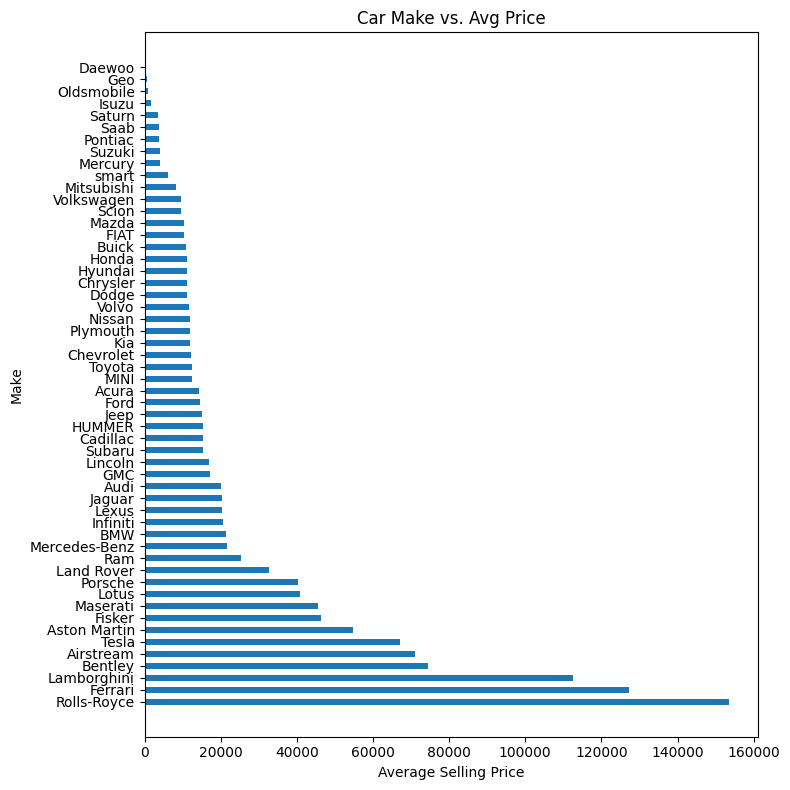

In [ ]:
#Visualization 2: BarChart of Make and Avg selling price
vis2 = df2.copy()
plt.figure(figsize=(8, 8))
plt.barh(vis2["make"], vis2["avgprice"], height=0.5)
plt.xlabel("Average Selling Price")
plt.ylabel("Make")
plt.title("Car Make vs. Avg Price")
plt.tight_layout()
plt.show

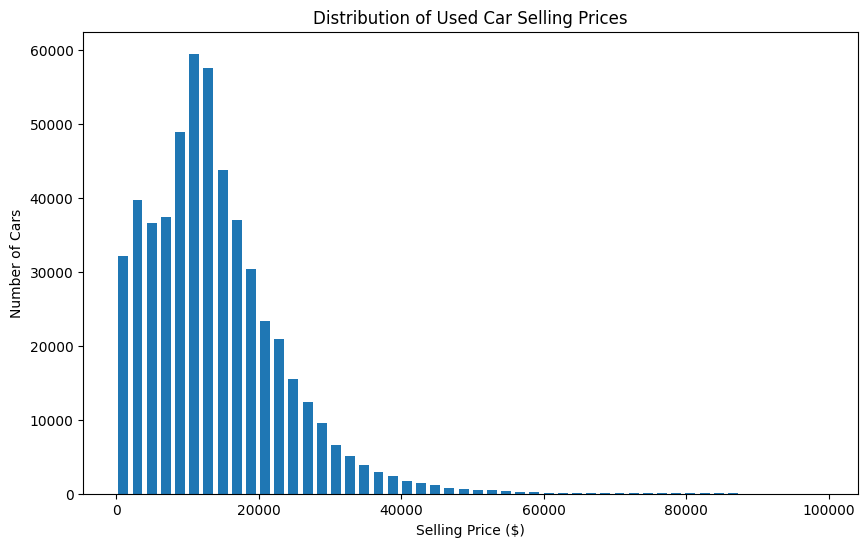

In [ ]:
#Visualization 3: Histogram Price Distribution
vis3 = df3.copy()
plt.figure(figsize=(10,6))
plt.hist(vis3["sellingprice"], bins=50, rwidth=0.7)
plt.title("Distribution of Used Car Selling Prices")
plt.xlabel("Selling Price ($)")
plt.ylabel("Number of Cars")
plt.show()

In [5]:
#Evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score,accuracy_score,root_mean_squared_log_error

def evaluate_model(y_test, y_pred):
  mse = mean_squared_error(y_test, y_pred)
  mae = mean_absolute_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  #acc = accuracy_score(y_test, y_pred)
  rmsle = root_mean_squared_log_error(y_test, y_pred)
  print("Mean Squared Error:", mse)
  print("Mean Absolute Error:", mae)
  print("R-squared:", r2)
  #print("Accuracy:", acc)
  print("Root Mean Squared Log Error:", rmsle)


Linear Regression Model Results
Mean Squared Error: 12135373.980513565
Mean Absolute Error: 2177.598857162811
R-squared: 0.871384334684902
Root Mean Squared Log Error: 0.28887130626490987


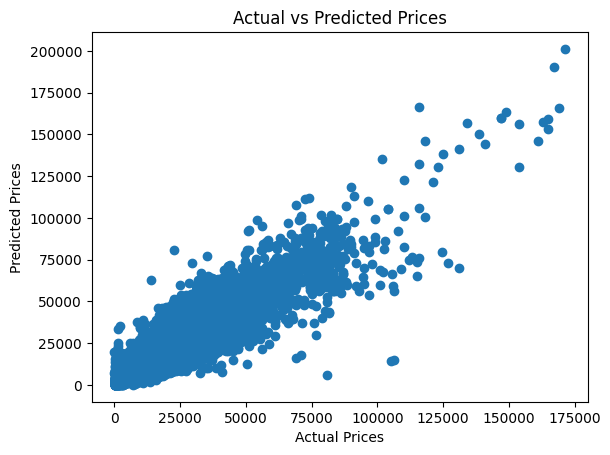

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn import preprocessing

#df cleanup and merge makemodel
df1 = df.copy()
df1["Make_Model"] = df1["make"] + " " + df1["model"]
df1 = df1.drop(["make", "model"], axis=1)
df1["Make_Model"] = df1["Make_Model"].fillna("Unknown")
#HotEncode catagorical values
df1 = pd.get_dummies(df1, columns=["Make_Model"],drop_first=True)
df1 = pd.get_dummies(df1, columns=["body"],drop_first=True)
df1 = pd.get_dummies(df1, columns=["transmission"],drop_first=True)
df1 = pd.get_dummies(df1, columns=["state"], drop_first=True)

x = df1.drop('sellingprice', axis=1) #seperate dependent and independent variables
y = np.log(df1['sellingprice'])

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3) #30 test 70 training
y_test_copy = y_test.copy()

#Seperates columns containing nums so catagorical data isnt standardized
numeric_cols = ['year', 'condition', 'odometer']

scaler = preprocessing.StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols]  = scaler.transform(X_test[numeric_cols])

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = np.exp(model.predict(X_test_scaled))

print("Linear Regression Model Results")
evaluate_model(np.exp(y_test), y_pred)

plt.scatter(np.exp(y_test), y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()



MAE: 1708.6348113256533
RMSE: 2819.2507662618627
R^2: 0.9151136973785421
KNN Model Results
Mean Squared Error: 7948174.8830681
Mean Absolute Error: 1708.6348113256533
R-squared: 0.9151136973785421


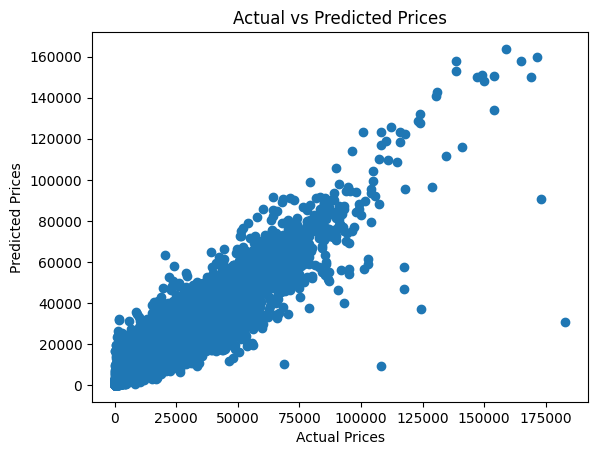

In [ ]:
# K Nearest Neighbor

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df.drop("sellingprice", axis=1)
y = df["sellingprice"].astype(float)

num_cols = X.select_dtypes(include=["number"]).columns
cat_cols = X.select_dtypes(exclude=["number"]).columns

prep = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ]
)

model = Pipeline([
    ("prep", prep),
    ("knn", KNeighborsRegressor(n_neighbors=5, weights="distance"))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R^2:", r2)

print("KNN Model Results")
evaluate_model(y_test, y_pred)

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()
